# Consolidation des adresses entre les annuaires de 1807 et 1808

Exploration : à partir de la **jointure** des deux annuaires alignés
(`numrev join`), peut-on produire des entrées à l'adresse
« consolidée » ? Pour chaque paire d'entrées appariées, on compare le champ
`adresse` (texte des empans `ADDR`) des deux éditions et on le classe :

| Classe | Règle |
|---|---|
| **équivalence** | deux adresses simples, même rue (à ε près : bruit OCR, graphies), même numéro |
| **changement de numéro** | deux adresses simples, même rue, numéros différents — à vérifier |
| **déménagement** | deux adresses simples, rues différentes |
| **adresse complexe** | au moins une adresse non simple : plusieurs adresses, description longue, etc. |

Une adresse est **simple** si elle a la forme `<rue>, <numéro>[.][texte sans chiffre]`.

Deux classes s'ajoutent pour les cas que ces règles ne couvrent pas, afin de
ne pas les noyer dans « adresse complexe » :

| Classe | Règle |
|---|---|
| **sans numéro** | au moins une adresse réduite à une rue, sans numéro (« rue des Fourreurs. ») |
| **adresse absente** | au moins une des deux entrées n'a pas d'empan `ADDR` |

Le notebook se termine par l'export d'un CSV : la jointure, plus la classe de
consolidation et les champs d'analyse.

## Paramètres et données

In [1]:
import os
import re
import subprocess
import sys
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz import fuzz

# Exécution depuis explorations/ (Jupyter) ou depuis la racine du dépôt.
ROOT = Path.cwd().parent if Path.cwd().name == "explorations" else Path.cwd()
os.chdir(ROOT)

# Alignement exploité : méthode ordonnée (NW) ; pour Dedupe + patch, prendre
# le CSV final `…/1807_AD75-PER292__1808_AD75-PER292.csv`.
ALIGNEMENT = Path("annuaires/alignments/1807_AD75-PER292__1808_AD75-PER292.nw.csv")
JOINTURE = ALIGNEMENT.with_name(f"{ALIGNEMENT.name.removesuffix('.csv')}.join.csv")
SORTIE = JOINTURE.with_name(f"{JOINTURE.name.removesuffix('.csv')}.consolidated.csv")
EPSILON = 0.85  # similarité minimale (0-1) de deux noms de rue normalisés pour « même rue »
EXCEL = False  # True : export `;` + UTF-8 avec BOM, pour un tableur en français

if not JOINTURE.exists():  # la jointure se régénère à partir de l'alignement
    subprocess.run([sys.executable, "-m", "numrev", "join", str(ALIGNEMENT), "-o", str(JOINTURE), "--apply"], check=True, capture_output=True)
    print(f"Jointure régénérée : {JOINTURE}")

jointure = pd.read_csv(JOINTURE, dtype=str, keep_default_na=False)
paires = jointure[jointure["statut"] == "apparié"].copy()
print(f"{len(jointure):,} lignes dans la jointure, dont {len(paires):,} paires".replace(",", " "))
jointure["statut"].value_counts()

18 990 lignes dans la jointure  dont 14 491 paires


statut
apparié             14491
gauche seulement     2897
droite seulement     1602
Name: count, dtype: int64

## Analyse d'une adresse

- **Adresse simple** : `<rue>` sans chiffre ni `;`, une virgule facultative
  (elle manque parfois : « rue de Grenelle-St.-Germ. 50. »), un numéro
  (éventuellement une plage « 16-18 », traitée comme un ensemble de
  numéros : « 21-19 » = « 19-21 »), un point facultatif, puis un texte sans
  chiffre (« bis », « au premier »…). La `<rue>` peut contenir des virgules
  (« palais du Tribunal, galerie de bois, 208 »).
- **Sans numéro** : une rue seule, sans chiffre, virgule ni `;`.
- Tout le reste est **complexe** : plusieurs numéros (« 1 et 43 »),
  plusieurs adresses (« …, 11; et rue …, 18 »), description (« rue du
  Temple, presque vis-à-vis la rue de la Corderie »).

Les noms de rue sont **normalisés** avant comparaison : césures d'OCR
recollées (« Bourdon- nais »), accents, casse et ponctuation retirés,
abréviations développées (`S.`/`St.` → saint, `Faub.`/`Fb.` → faubourg,
`r.` → rue, `N.` → neuve…), articles et prépositions retirés (« rue de
Sorbonne » = « rue Sorbonne »), « rue du Faubourg-X » = « faubourg X ».

In [2]:
SIMPLE = re.compile(r"^(?P<rue>[^\d;]+?)\s*[,;]?\s*(?P<numero>\d+(?:\s*-\s*\d+)?)\s*\.?\s*(?P<reste>[^\d]*)$")
SANS_NUMERO = re.compile(r"^[^\d,;]+$")
ABREVIATIONS = [
    (r"\br\b", "rue"), (r"\bste\b", "sainte"), (r"\b(?:st|s)\b", "saint"),
    (r"\b(?:faub|faubg|fb|f)\b", "faubourg"), (r"\bn\b", "neuve"), (r"\bgerm\b", "germain"),
    (r"\bpass\b", "passage"), (r"\b(?:boul|boulev|bd)\b", "boulevard"), (r"\bpet\b", "petite"),
    (r"\bgr\b", "grande"), (r"\bpal\b", "palais"), (r"\bgal\b", "galerie"),
]
MOTS_VIDES = {"de", "du", "des", "la", "le", "les", "d", "l", "a", "au", "aux", "en"}


def normaliser_rue(rue: str) -> str:
    texte = re.sub(r"-\s+(?=[a-zà-ÿ])", "", rue)  # césure d'OCR : « Bourdon- nais »
    texte = "".join(c for c in unicodedata.normalize("NFD", texte) if not unicodedata.combining(c)).lower()
    texte = re.sub(r"[\W_]+", " ", texte)
    for motif, forme in ABREVIATIONS:
        texte = re.sub(motif, forme, texte)
    mots = [mot for mot in texte.split() if mot not in MOTS_VIDES]
    if mots[:2] == ["rue", "faubourg"]:
        mots = mots[1:]
    return " ".join(mots)


def numeros(numero: str) -> frozenset[int]:
    return frozenset(int(n) for n in re.findall(r"\d+", numero))


def analyser(adresse: str) -> dict:
    """Type d'adresse (simple / sans numéro / complexe / absente), rue normalisée et numéros."""
    adresse = adresse.strip()
    if not adresse:
        return {"type": "absente", "rue": "", "numeros": frozenset()}
    if match := SIMPLE.match(adresse):
        return {"type": "simple", "rue": normaliser_rue(match["rue"]), "numeros": numeros(match["numero"])}
    if SANS_NUMERO.match(adresse.rstrip(".")):
        return {"type": "sans numéro", "rue": normaliser_rue(adresse), "numeros": frozenset()}
    return {"type": "complexe", "rue": "", "numeros": frozenset()}


for exemple in ["rue du Faub.-S.-Laurent, 33.", "rue de Cléry, 21-19.", "r. Basse-du-Rempart, 26.",
                "rue des Bourdon- nais, 14.", "rue Mézières.", "quai de l'Horloge, 1 et 43.",
                "rue du Mail, 19; et rue J.-J.- Rousseau, 13.", ""]:
    print(f"{exemple!r:48} → {analyser(exemple)}")

'rue du Faub.-S.-Laurent, 33.'                   → {'type': 'simple', 'rue': 'faubourg saint laurent', 'numeros': frozenset({33})}
'rue de Cléry, 21-19.'                           → {'type': 'simple', 'rue': 'rue clery', 'numeros': frozenset({19, 21})}
'r. Basse-du-Rempart, 26.'                       → {'type': 'simple', 'rue': 'rue basse rempart', 'numeros': frozenset({26})}
'rue des Bourdon- nais, 14.'                     → {'type': 'simple', 'rue': 'rue bourdonnais', 'numeros': frozenset({14})}
'rue Mézières.'                                  → {'type': 'sans numéro', 'rue': 'rue mezieres', 'numeros': frozenset()}
"quai de l'Horloge, 1 et 43."                    → {'type': 'complexe', 'rue': '', 'numeros': frozenset()}
'rue du Mail, 19; et rue J.-J.- Rousseau, 13.'   → {'type': 'complexe', 'rue': '', 'numeros': frozenset()}
''                                               → {'type': 'absente', 'rue': '', 'numeros': frozenset()}


## Classement des paires

Même rue si la similarité des noms normalisés (`rapidfuzz.fuzz.ratio`,
distance d'édition normalisée, entre 0 et 1) est au moins ε. L'ordre des
règles : absente, puis complexe, puis sans numéro, puis la comparaison de
deux adresses simples.

In [3]:
CLASSES = ["équivalence", "changement de numéro", "déménagement", "adresse complexe", "sans numéro", "adresse absente"]


def similarite_rue(gauche: str, droite: str) -> float:
    return fuzz.ratio(gauche, droite) / 100


def classer(gauche: dict, droite: dict) -> str:
    types = {gauche["type"], droite["type"]}
    if "absente" in types:
        return "adresse absente"
    if "complexe" in types:
        return "adresse complexe"
    if "sans numéro" in types:
        return "sans numéro"
    if similarite_rue(gauche["rue"], droite["rue"]) < EPSILON:
        return "déménagement"
    return "équivalence" if gauche["numeros"] == droite["numeros"] else "changement de numéro"


def un_chiffre_differe(gauche: frozenset[int], droite: frozenset[int]) -> bool:
    """Deux numéros uniques de même longueur qui ne diffèrent que d'un chiffre (« 55 » / « 33 » non : deux chiffres)."""
    if len(gauche) != 1 or len(droite) != 1:
        return False
    a, b = str(next(iter(gauche))), str(next(iter(droite)))
    return len(a) == len(b) and sum(x != y for x, y in zip(a, b)) == 1


def chiffres_substitues(gauche: frozenset[int], droite: frozenset[int]) -> str:
    """« 5→3 » quand un seul chiffre diffère (voir `un_chiffre_differe`), vide sinon."""
    if not un_chiffre_differe(gauche, droite):
        return ""
    a, b = str(next(iter(gauche))), str(next(iter(droite)))
    return next(f"{x}→{y}" for x, y in zip(a, b) if x != y)


def nom_inclus(gauche: str, droite: str) -> bool:
    """Les mots d'un nom de rue sont tous dans l'autre, plus long (« rue four » / « rue four saint germain ») :
    nom précisé plutôt que déménagement — ou deux rues distinctes (rue de Grenelle-Saint-Honoré / -Saint-Germain)."""
    court, long = sorted((set(gauche.split()), set(droite.split())), key=len)
    return len(court) >= 2 and court < long


def formater(numeros: frozenset[int]) -> str:
    return "-".join(str(n) for n in sorted(numeros))


analyses_g = paires["gauche_adresse"].map(analyser)
analyses_d = paires["droite_adresse"].map(analyser)
paires["consolidation"] = [classer(g, d) for g, d in zip(analyses_g, analyses_d)]
for cote, analyses in (("gauche", analyses_g), ("droite", analyses_d)):
    paires[f"{cote}_type_adresse"] = analyses.map(lambda a: a["type"])
    paires[f"{cote}_rue_normalisee"] = analyses.map(lambda a: a["rue"])
    paires[f"{cote}_numero"] = analyses.map(lambda a: formater(a["numeros"]))
paires["similarite_rue"] = [
    round(similarite_rue(g["rue"], d["rue"]), 3) if g["rue"] and d["rue"] else np.nan for g, d in zip(analyses_g, analyses_d)
]
paires["meme_numero"] = [bool(g["numeros"]) and g["numeros"] == d["numeros"] for g, d in zip(analyses_g, analyses_d)]
paires["un_chiffre_differe"] = [un_chiffre_differe(g["numeros"], d["numeros"]) for g, d in zip(analyses_g, analyses_d)]
paires["chiffres_substitues"] = [chiffres_substitues(g["numeros"], d["numeros"]) for g, d in zip(analyses_g, analyses_d)]
paires["nom_inclus"] = [nom_inclus(g["rue"], d["rue"]) for g, d in zip(analyses_g, analyses_d)]

bilan = paires["consolidation"].value_counts().reindex(CLASSES, fill_value=0).to_frame("paires")
bilan["part"] = (bilan["paires"] / bilan["paires"].sum()).map("{:.1%}".format)
bilan

,paires,part
consolidation,,
équivalence,9539,65.8%
changement de numéro,2096,14.5%
déménagement,1564,10.8%
adresse complexe,442,3.1%
sans numéro,563,3.9%
adresse absente,287,2.0%


## Visualisations

Couleurs : une teinte par classe, dans un ordre fixe, commune à tous les
graphiques ; les valeurs sont toujours écrites (ou données dans un tableau)
car trois teintes sont peu contrastées sur fond clair.

In [4]:
COULEURS = dict(zip(CLASSES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]))
TEXTE, TEXTE_SECONDAIRE, GRILLE = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRILLE,
    "axes.labelcolor": TEXTE_SECONDAIRE, "xtick.color": TEXTE_SECONDAIRE, "ytick.color": TEXTE_SECONDAIRE,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRILLE,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlecolor": TEXTE, "axes.titlelocation": "left",
})


def barres_horizontales(ax, etiquettes, valeurs, couleurs, format_valeur="{:,}"):
    y = np.arange(len(valeurs))
    ax.barh(y, valeurs, color=couleurs, height=0.7, edgecolor="#fcfcfb", linewidth=2)
    ax.set_yticks(y, etiquettes)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    for i, valeur in enumerate(valeurs):
        ax.text(valeur, i, " " + format_valeur.format(valeur).replace(",", " "), va="center", color=TEXTE, fontsize=9)

### Répartition des classes

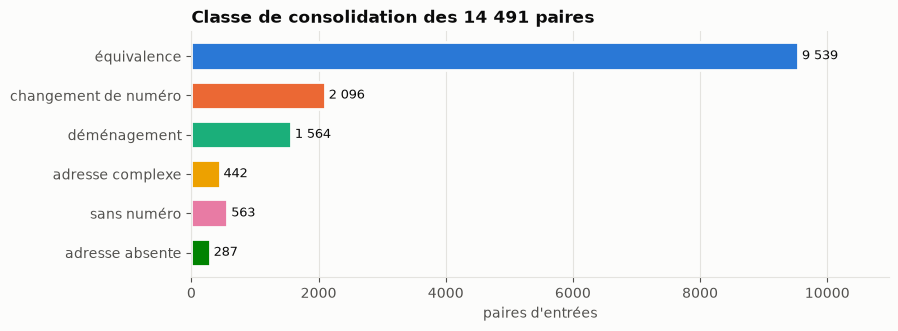

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.2))
barres_horizontales(ax, bilan.index, bilan["paires"], [COULEURS[c] for c in bilan.index])
ax.set_title(f"Classe de consolidation des {len(paires):,} paires".replace(",", " "))
ax.set_xlabel("paires d'entrées")
ax.set_xlim(0, bilan["paires"].max() * 1.15)
plt.show()

### Similarité des noms de rue

Pour les paires de deux adresses simples. Le seuil ε sépare « même rue » de
« déménagement » ; l'échelle verticale est logarithmique, car l'immense
majorité des paires a des rues identiques après normalisation.

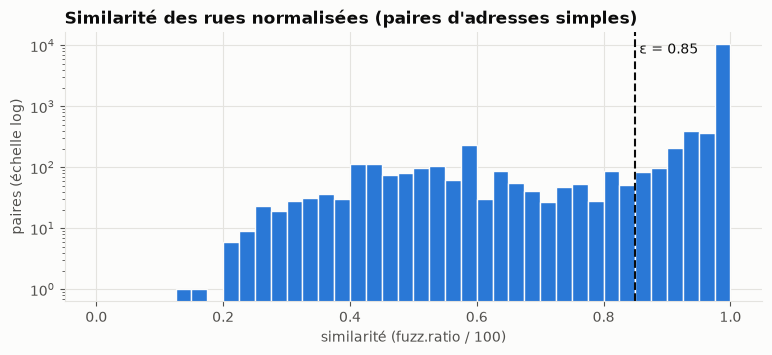

,paires
similarite_rue,
"(-0.0001, 0.5]",611
"(0.5, 0.7]",661
"(0.7, 0.8]",184
"(0.8, 0.85]",110
"(0.85, 0.9]",220
"(0.9, 0.95]",560
"(0.95, 0.9999]",414
"(0.9999, 1.0]",10439


In [6]:
simples = paires[(paires["gauche_type_adresse"] == "simple") & (paires["droite_type_adresse"] == "simple")]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(simples["similarite_rue"], bins=np.linspace(0, 1, 41), color="#2a78d6", edgecolor="#fcfcfb", linewidth=1)
ax.axvline(EPSILON, color=TEXTE, linewidth=1.5, linestyle="--")
ax.text(EPSILON, ax.get_ylim()[1], f" ε = {EPSILON}", va="top", color=TEXTE)
ax.set_yscale("log")
ax.set_title("Similarité des rues normalisées (paires d'adresses simples)")
ax.set_xlabel("similarité (fuzz.ratio / 100)")
ax.set_ylabel("paires (échelle log)")
plt.show()

tranches = pd.cut(simples["similarite_rue"], [0, 0.5, 0.7, 0.8, EPSILON, 0.9, 0.95, 0.9999, 1], include_lowest=True)
tranches.value_counts().sort_index().to_frame("paires")

Cas limites autour du seuil, pour juger ε à l'œil : au-dessus, des variantes
OCR d'une même rue ; en dessous, des rues voisines ou homonymes à préciser
(« rue de Grenelle » / « rue de Grenelle-Saint-Germain » sont deux rues
distinctes à Paris, comme « rue de Beaune » / « rue de Beauce »).

In [7]:
limites = simples[simples["similarite_rue"].between(EPSILON - 0.1, EPSILON + 0.08)]
colonnes = ["similarite_rue", "gauche_adresse", "droite_adresse", "consolidation"]
limites.sample(min(30, len(limites)), random_state=0).sort_values("similarite_rue")[colonnes]

,similarite_rue,gauche_adresse,droite_adresse,consolidation
9551,0.750,"quai de la Liberté, 20.","quai de Béthune, 20.",déménagement
1250,0.824,"rue Vieux-du-Temple, 158.","rue Vieille-du-Temple, 138.",déménagement
8957,0.824,"rue Saint-Méry, 44.","rue N.-St.-Méry, 44.",déménagement
7095,0.824,"rue du Faubourg-du-Roule, 92.","rue du Faubourg- du-Roule, 92.",déménagement
3792,0.839,"rue Bourbonbourg, 24.","rue Bourtibourg, 24.",déménagement
6535,0.850,"rue Saint-Nicolas, 56.","rue Saint-Nicolas-d'Antin, 36.",changement de numéro
5892,0.853,"rue des Francs-Bourgeois-S.-Michel, 5.","rue des Frances-Bourgeois-St.-Germain, 3.",changement de numéro
12643,0.857,"rue Béthisy, 10.","rue Bétizy, 10.",équivalence
2651,0.857,"rue du Boulois, 10.","rue du Bouloy, 10.",équivalence
16525,0.857,"rue Richepouse, 2.","rue Richepanse, 2.",équivalence


### Changements de numéro : bruit d'OCR ou renumérotation ?

Si les deux numéros ne diffèrent que d'un chiffre, lequel est remplacé par
lequel ? Une matrice concentrée sur quelques couples (3 ↔ 5, 1 ↔ 7…) signe
une confusion typographique ou d'OCR, pas un changement réel.

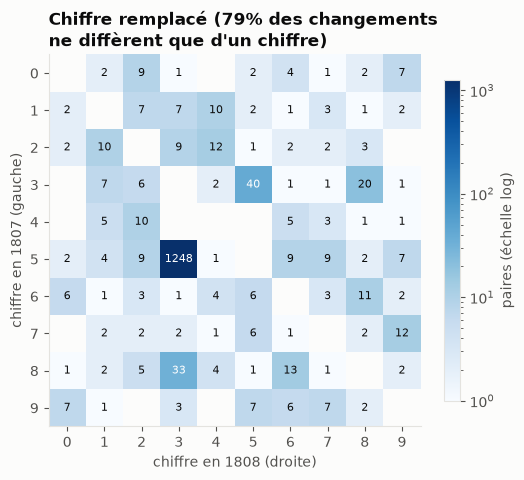

,paires
chiffres_substitues,
5→3,1248
plusieurs chiffres ou plage,438
3→5,40
8→3,33
3→8,20
8→6,13
2→4,12
7→9,12
6→8,11


In [8]:
changements = paires[paires["consolidation"] == "changement de numéro"]
confusions = np.zeros((10, 10), dtype=int)
for gauche, droite in zip(changements["gauche_numero"], changements["droite_numero"]):
    if "-" not in gauche and "-" not in droite and len(gauche) == len(droite):
        differences = [(int(a), int(b)) for a, b in zip(gauche, droite) if a != b]
        if len(differences) == 1:
            confusions[differences[0]] += 1

part_un_chiffre = changements["un_chiffre_differe"].mean()
fig, ax = plt.subplots(figsize=(6, 5.2))
image = ax.imshow(np.ma.masked_equal(confusions, 0), cmap="Blues", norm=plt.matplotlib.colors.LogNorm(vmin=1))
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.grid(False)
for (i, j), n in np.ndenumerate(confusions):
    if n:
        ax.text(j, i, n, ha="center", va="center", fontsize=8, color="white" if n > 30 else TEXTE)
ax.set_title(f"Chiffre remplacé ({part_un_chiffre:.0%} des changements\nne diffèrent que d'un chiffre)")
ax.set_xlabel("chiffre en 1808 (droite)")
ax.set_ylabel("chiffre en 1807 (gauche)")
fig.colorbar(image, ax=ax, shrink=0.8, label="paires (échelle log)")
plt.show()

changements["chiffres_substitues"].replace("", "plusieurs chiffres ou plage").value_counts().head(10).to_frame("paires")

Écart entre les deux numéros (premier numéro de chaque côté) : un petit écart
évoque une coquille ou un numéro voisin ; un grand écart, une renumérotation
ou une erreur d'alignement.

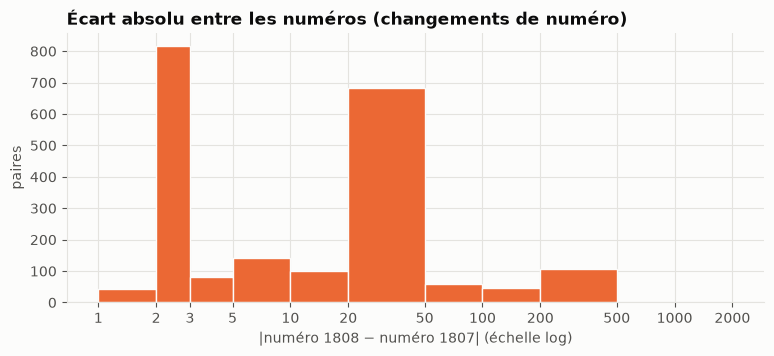

,paires
"(0, 1]",43
"(1, 2]",817
"(2, 9]",225
"(9, 99]",844
"(99, 10000]",153


In [9]:
premier = lambda numero: int(numero.split("-")[0])
ecarts = (changements["droite_numero"].map(premier) - changements["gauche_numero"].map(premier)).abs()
fig, ax = plt.subplots(figsize=(9, 3.5))
bornes = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
ax.hist(ecarts, bins=bornes, color=COULEURS["changement de numéro"], edgecolor="#fcfcfb", linewidth=1)
ax.set_xscale("log")
ax.set_xticks(bornes, [str(b) for b in bornes])
ax.minorticks_off()
ax.set_title("Écart absolu entre les numéros (changements de numéro)")
ax.set_xlabel("|numéro 1808 − numéro 1807| (échelle log)")
ax.set_ylabel("paires")
plt.show()
pd.cut(ecarts, [0, 1, 2, 9, 99, 10_000]).value_counts().sort_index().to_frame("paires")

### Déménagements : vrais changements ou rues renommées ?

Les transitions de rue les plus fréquentes. Une transition répétée **au même
numéro** désigne très probablement un renommage de la rue, pas un
déménagement : 1806-1807 voit le retour de noms d'Ancien Régime (rue de la
Loi → rue de Richelieu…).

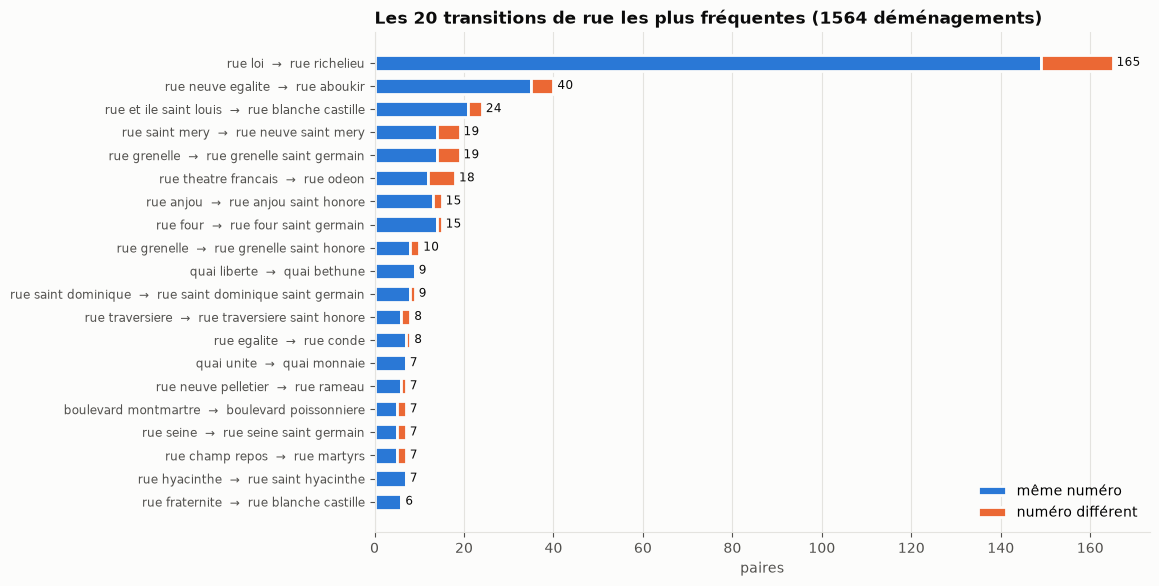

,total,meme_numero
transition,,
rue loi → rue richelieu,165,149
rue neuve egalite → rue aboukir,40,35
rue et ile saint louis → rue blanche castille,24,21
rue saint mery → rue neuve saint mery,19,14
rue grenelle → rue grenelle saint germain,19,14
rue theatre francais → rue odeon,18,12
rue anjou → rue anjou saint honore,15,13
rue four → rue four saint germain,15,14
rue grenelle → rue grenelle saint honore,10,8


In [10]:
demenagements = paires[paires["consolidation"] == "déménagement"].copy()
demenagements["transition"] = demenagements["gauche_rue_normalisee"] + "  →  " + demenagements["droite_rue_normalisee"]
transitions = (
    demenagements.groupby("transition")["meme_numero"].agg(total="size", meme_numero="sum")
    .sort_values("total", ascending=False)
)
top = transitions.head(20)

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(top))
ax.barh(y, top["meme_numero"], color="#2a78d6", height=0.7, label="même numéro", edgecolor="#fcfcfb", linewidth=2)
ax.barh(y, top["total"] - top["meme_numero"], left=top["meme_numero"], color="#eb6834", height=0.7,
        label="numéro différent", edgecolor="#fcfcfb", linewidth=2)
ax.set_yticks(y, top.index, fontsize=8.5)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
for i, total in enumerate(top["total"]):
    ax.text(total, i, f" {total}", va="center", fontsize=8.5, color=TEXTE)
ax.legend(loc="lower right", frameon=False)
ax.set_title(f"Les 20 transitions de rue les plus fréquentes ({len(demenagements)} déménagements)")
ax.set_xlabel("paires")
plt.show()

top

Les déménagements se décomposent selon deux indices qui suggèrent un
**renommage** ou une **précision du nom** plutôt qu'un déménagement :
même numéro dans les deux éditions, et nom de l'une inclus dans celui de
l'autre (`nom_inclus`). Seuls les déménagements sans aucun des deux indices
sont des candidats sérieux à un vrai changement d'adresse.

In [11]:
indices = pd.crosstab(
    demenagements["meme_numero"].map({True: "même numéro", False: "numéro différent"}),
    demenagements["nom_inclus"].map({True: "nom inclus", False: "noms distincts"}),
    margins=True, margins_name="total",
)
indices

nom_inclus,nom inclus,noms distincts,total
meme_numero,,,
même numéro,206,536,742
numéro différent,60,762,822
total,266,1298,1564


### Score d'alignement par classe

Un déménagement ou un changement de numéro peut aussi venir d'une **paire
mal alignée**. Si leurs scores sont nettement plus bas que ceux des
équivalences, une partie de ces classes est à imputer à l'alignement.

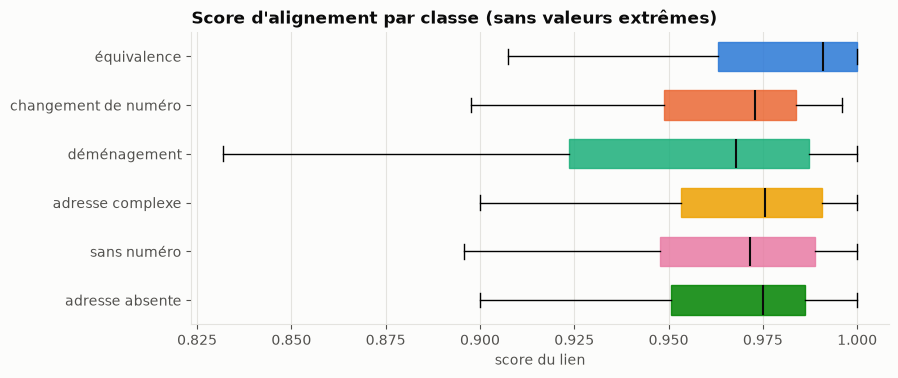

,count,25%,50%,75%
consolidation,,,,
équivalence,9539.0,0.963,0.991,1.000
changement de numéro,2096.0,0.949,0.973,0.984
déménagement,1564.0,0.924,0.968,0.987
adresse complexe,442.0,0.953,0.976,0.991
sans numéro,563.0,0.948,0.972,0.989
adresse absente,287.0,0.951,0.975,0.986


In [12]:
scores = paires.assign(score=pd.to_numeric(paires["score"], errors="coerce")).dropna(subset=["score"])
presentes = [c for c in CLASSES if (scores["consolidation"] == c).any()]
fig, ax = plt.subplots(figsize=(9, 3.8))
boites = ax.boxplot(
    [scores.loc[scores["consolidation"] == c, "score"] for c in presentes], patch_artist=True,
    widths=0.6, showfliers=False, orientation="horizontal", medianprops={"color": TEXTE, "linewidth": 1.5},
)
for boite, classe in zip(boites["boxes"], presentes):
    boite.set(facecolor=COULEURS[classe], edgecolor=COULEURS[classe], alpha=0.85)
ax.set_yticks(range(1, len(presentes) + 1), presentes)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title("Score d'alignement par classe (sans valeurs extrêmes)")
ax.set_xlabel("score du lien")
plt.show()
scores.groupby("consolidation")["score"].describe()[["count", "25%", "50%", "75%"]].reindex(presentes).round(3)

### Par rubrique

Part de chaque classe dans les 20 rubriques (de 1807) qui comptent le plus
de paires : les rubriques riches en adresses complexes ou sans numéro
(institutions, listes) se distinguent des professions à adresse simple.

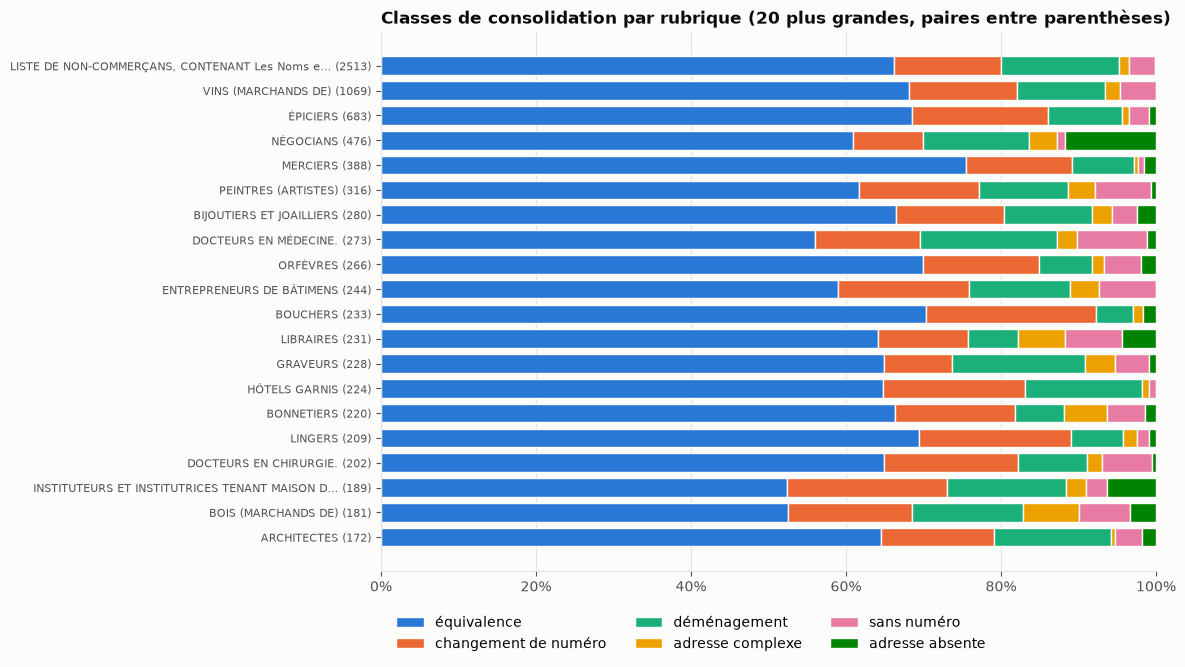

consolidation,équivalence,changement de numéro,déménagement,adresse complexe,sans numéro,adresse absente
gauche_rubrique,,,,,,
"LISTE DE NON-COMMERÇANS, CONTENANT Les Noms et Adresses des principaux Habitans de PARIS, qui n'exercent aucun commerce.",1664,347,381,32,87,2
VINS (MARCHANDS DE),728,149,121,22,49,0
ÉPICIERS,468,120,65,6,18,6
NÉGOCIANS,290,43,65,17,5,56
MERCIERS,293,53,31,2,3,6
PEINTRES (ARTISTES),195,49,36,11,23,2
BIJOUTIERS ET JOAILLIERS,186,39,32,7,9,7
DOCTEURS EN MÉDECINE.,153,37,48,7,25,3
ORFÈVRES,186,40,18,4,13,5


In [13]:
par_rubrique = pd.crosstab(paires["gauche_rubrique"], paires["consolidation"]).reindex(columns=CLASSES, fill_value=0)
par_rubrique = par_rubrique.loc[par_rubrique.sum(axis=1).sort_values(ascending=False).index[:20]]
parts = par_rubrique.div(par_rubrique.sum(axis=1), axis=0)
etiquettes = [f"{r[:45]}{'…' if len(r) > 45 else ''} ({n})" for r, n in zip(parts.index, par_rubrique.sum(axis=1))]

fig, ax = plt.subplots(figsize=(10, 7))
gauche = np.zeros(len(parts))
for classe in CLASSES:
    ax.barh(etiquettes, parts[classe], left=gauche, color=COULEURS[classe], label=classe, height=0.75,
            edgecolor="#fcfcfb", linewidth=1)
    gauche += parts[classe].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.4, -0.06), frameon=False)
ax.set_title("Classes de consolidation par rubrique (20 plus grandes, paires entre parenthèses)")
plt.show()
par_rubrique

## Constats (alignement NW 1807/1808, exécution du 29 septembre 2026)

- Environ **deux tiers des paires sont des équivalences** : leur adresse est
  consolidée directement.
- La grande majorité des **changements de numéro** ne diffèrent que d'un
  chiffre, et l'essentiel de ceux-là est un **5 de 1807 lu 3 en 1808**,
  presque jamais l'inverse : une confusion systématique (police d'un des deux
  volumes ou OCR), pas un changement réel. Les scans diront quelle édition a
  raison ; une fois tranchée, ces paires basculent en équivalence.
- Près de la moitié des **déménagements** gardent le même numéro : ce sont
  surtout des **rues renommées** entre les deux éditions (rue de la Loi → rue
  de Richelieu, rue Neuve-de-l'Égalité → rue d'Aboukir, quai de la Liberté →
  quai de Béthune, quai de l'Unité → quai des Monnaies : retour de noms
  d'Ancien Régime ou nouveaux noms) ou des **noms précisés** en 1808 (rue du
  Four → rue du Four-Saint-Germain). Une table de concordance des rues
  renommées, construite à partir de ces transitions, permettrait de les
  requalifier en équivalences.
- Les scores d'alignement des déménagements sont un peu plus bas : une
  partie vient sans doute de paires mal alignées.

## Export du CSV consolidé

Toutes les lignes de la jointure (les entrées sans correspondance gardent une
classe vide), avec :

- `consolidation` : la classe de la paire ;
- `adresse_consolidee` : pour une **équivalence**, l'adresse telle qu'imprimée
  en 1808 (dernière forme attestée) ; vide sinon, ces cas restant à trancher ;
- les champs d'analyse : `gauche_/droite_type_adresse`, `…_rue_normalisee`,
  `…_numero`, `similarite_rue`, `meme_numero`, `un_chiffre_differe`,
  `chiffres_substitues` (« 5→3 »), `nom_inclus`.

In [14]:
AJOUTS = [
    "consolidation", "adresse_consolidee", "similarite_rue", "meme_numero", "un_chiffre_differe",
    "chiffres_substitues", "nom_inclus",
    "gauche_type_adresse", "gauche_rue_normalisee", "gauche_numero",
    "droite_type_adresse", "droite_rue_normalisee", "droite_numero",
]
paires["adresse_consolidee"] = paires["droite_adresse"].where(paires["consolidation"] == "équivalence", "")
consolide = jointure.join(paires[AJOUTS])
colonnes = [*jointure.columns[:4], *AJOUTS, *jointure.columns[4:]]
consolide = consolide[colonnes]
for colonne in ("meme_numero", "un_chiffre_differe", "nom_inclus"):
    consolide[colonne] = consolide[colonne].map({True: "oui", False: "non"}).fillna("")
consolide = consolide.fillna("")

consolide.to_csv(SORTIE, index=False, sep=";" if EXCEL else ",", encoding="utf-8-sig" if EXCEL else "utf-8")
print(f"{len(consolide):,} lignes → {SORTIE}".replace(",", " "))
consolide[consolide["statut"] == "apparié"].head(5)

18 990 lignes → annuaires/alignments/1807_AD75-PER292__1808_AD75-PER292.nw.join.consolidated.csv


,statut,score,methode,rubriques_correspondantes,consolidation,adresse_consolidee,similarite_rue,meme_numero,un_chiffre_differe,chiffres_substitues,...,gauche_uuid,droite_volume,droite_page,droite_rubrique,droite_texte,droite_sujet,droite_description,droite_adresse,droite_texte_balise,droite_uuid
0,apparié,0.9868,nw-contexte,oui,équivalence,"rue Duphot, 4.",1.0,oui,non,,...,9bb0d225-2718-5204-93d0-33b361909098,1808_AD75-PER292,6,AGENS DE CHANGE,"ARCHÉDÉACON, (Ed.) rue Duphot, 4.","ARCHÉDÉACON, (Ed.)",,"rue Duphot, 4.","<SUBJ>ARCHÉDÉACON, (Ed.)</SUBJ> <ADDR>rue Duph...",6f27e297-15ef-5ea4-a370-b183e9e8d256
1,apparié,0.9956,nw-contexte,oui,équivalence,"rue du Helder, 9.",1.0,oui,non,,...,32f6e5a6-89f8-5352-bef7-aa78fd3e72fc,1808_AD75-PER292,6,AGENS DE CHANGE,"Archédéacon, (Ch.) rue du Helder, 9.","Archédéacon, (Ch.)",,"rue du Helder, 9.","<SUBJ>Archédéacon, (Ch.)</SUBJ> <ADDR>rue du H...",468eb903-66fc-5e1f-97b8-730a4b3b3732
2,apparié,1.0000,nw,oui,équivalence,"rue de la Victoire, 54.",1.0,oui,non,,...,24e32dc1-7197-5cf5-9734-6165779e9d5d,1808_AD75-PER292,6,AGENS DE CHANGE,"Bailliot, rue de la Victoire, 54.",Bailliot,,"rue de la Victoire, 54.","<SUBJ>Bailliot</SUBJ>, <ADDR>rue de la Victoir...",2b88276b-d0e3-5a69-aa85-bd3e00e8a4c6
3,apparié,0.9714,nw,oui,changement de numéro,,1.0,non,non,,...,54454c6f-2faa-50c3-a10a-9e8615cb6acc,1808_AD75-PER292,6,AGENS DE CHANGE,"Beaumont, rue Basse-du-Rempart, 32.",Beaumont,,"rue Basse-du-Rempart, 32.","<SUBJ>Beaumont</SUBJ>, <ADDR>rue Basse-du-Remp...",7bd56131-968c-5ea8-b073-ffec0affaa99
4,apparié,1.0000,nw,oui,équivalence,"rue Helvétius, 23.",1.0,oui,non,,...,8dcf2ce5-c24b-5ad5-ad27-f0a73f37d7de,1808_AD75-PER292,6,AGENS DE CHANGE,"Besson aîné, rue Helvétius, 23.",Besson aîné,,"rue Helvétius, 23.","<SUBJ>Besson aîné</SUBJ>, <ADDR>rue Helvétius,...",cc083fca-f983-5849-8c5e-671076229031
